# Majorana Choi transfer spectrum

This notebook loads the saved complex Choi covariances from the largest cached Lyapunov run, converts each complex Choi block to a Majorana covariance block using equation 9 of `covariance_note (2).pdf`, constructs the transfer matrix from the Majorana Choi covariance, and plots `(1 / 2C) log spec(T T^dagger)`.

## Available cached Choi covariance configs

| Cache file | Nx | Ny | C | Samples | alpha_1 | alpha_2 | Saved Choi covariances |
|---|---:|---:|---:|---:|---:|---:|---|
| `lyapunov_spectrum_N16x20_C100_S25_a1_30_a2_1.npz` | 16 | 20 | 100 | 25 | 30 | 1 | `sampled_feedback_Psi_final` `(25, 1280, 1280)`; `perfect_correction_Psi_final` `(25, 1280, 1280)`; `post_selection_Psi_final` `(1, 1280, 1280)` |
| `lyapunov_spectrum_N12x16_C50_S25_a1_30_a2_1.npz` | 12 | 16 | 50 | 25 | 30 | 1 | `sampled_feedback_Psi_final` `(25, 768, 768)`; `perfect_correction_Psi_final` `(25, 768, 768)`; `post_selection_Psi_final` `(1, 768, 768)` |
| `lyapunov_spectrum_N12x16_C50_S25_a1_1_a2_1.npz` | 12 | 16 | 50 | 25 | 1 | 1 | `sampled_feedback_Psi_final` `(25, 768, 768)`; `perfect_correction_Psi_final` `(25, 768, 768)`; `post_selection_Psi_final` `(1, 768, 768)` |
| `lyapunov_spectrum_N12x16_C20_S10.npz` | 12 | 16 | 20 | 10 | - | - | `sampled_feedback_Psi_final` `(10, 768, 768)`; `post_selection_Psi_final` `(1, 768, 768)`; `perfect_correction_Psi_final` `(10, 768, 768)` |
| `lyapunov_spectrum_N8x8_C20_S10_a1_30_a2_1.npz` | 8 | 8 | 20 | 10 | 30 | 1 | `sampled_feedback_Psi_final` `(10, 256, 256)`; `perfect_correction_Psi_final` `(10, 256, 256)`; `post_selection_Psi_final` `(1, 256, 256)` |
| `lyapunov_spectrum_N8x8_C20_S10_a1_1_a2_1.npz` | 8 | 8 | 20 | 10 | 1 | 1 | `sampled_feedback_Psi_final` `(10, 256, 256)`; `perfect_correction_Psi_final` `(10, 256, 256)`; `post_selection_Psi_final` `(1, 256, 256)` |

In [1]:
from pathlib import Path
import json
import os

# CPU allocation. Edit this range before running the notebook.
LOCK_TO_CPU_RANGE = True
CPU_RANGE_START = 90
CPU_RANGE_STOP = CPU_RANGE_START + 10
CPU_THREAD_CAP = None  # None means use every accessible core in the selected range.

def configure_cpu_affinity(lock_to_range=True, start=0, stop=None, thread_cap=None):
    available = sorted(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity") else list(range(os.cpu_count() or 1))
    if stop is None:
        stop = max(available) + 1
    requested = [cpu for cpu in range(int(start), int(stop))]
    selected = [cpu for cpu in available if cpu in requested]
    if not selected:
        selected = available
    if thread_cap is not None:
        selected = selected[: max(1, int(thread_cap))]
    if lock_to_range and hasattr(os, "sched_setaffinity"):
        os.sched_setaffinity(0, set(selected))
    threads = max(1, len(selected))
    for var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_MAX_THREADS", "VECLIB_MAXIMUM_THREADS"):
        os.environ[var] = str(threads)
    return selected

SELECTED_CPUS = configure_cpu_affinity(
    lock_to_range=LOCK_TO_CPU_RANGE,
    start=CPU_RANGE_START,
    stop=CPU_RANGE_STOP,
    thread_cap=CPU_THREAD_CAP,
)
print(f"Using CPU cores: {SELECTED_CPUS[0]}-{SELECTED_CPUS[-1]} ({len(SELECTED_CPUS)} cores)")

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
ANALYSIS_DIR = cwd if cwd.name == "lyapunov_analysis_v2" else cwd / "lyapunov_analysis_v2"
CACHE_DIR = ANALYSIS_DIR / "cache"
FIG_DIR = ANALYSIS_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_FILE = CACHE_DIR / "lyapunov_spectrum_N16x20_C100_S25_a1_30_a2_1.npz"
OUTPUT_FIG = FIG_DIR / "majorana_transfer_spectrum_N16x20_C100.png"
OUTPUT_DATA = CACHE_DIR / "majorana_transfer_spectrum_N16x20_C100.npz"

PROTOCOL_KEYS = {
    "perfect_correction": "perfect_correction_Psi_final",
    "post_selection": "post_selection_Psi_final",
}

COND_CUTOFF = 1e12
PINV_RCOND = 1e-12
EIG_FLOOR = 1e-300

assert SOURCE_FILE.exists(), f"Missing cache file: {SOURCE_FILE}"
SOURCE_FILE

Using CPU cores: 90-99 (10 cores)


PosixPath('/home/abhuiyan/class_A_fermionic_adaptive_circuit/lyapunov_analysis_v2/cache/lyapunov_spectrum_N16x20_C100_S25_a1_30_a2_1.npz')

In [2]:
def split_complex_choi(Psi_c):
    """Split a complex Choi covariance into four equal blocks."""
    Psi_c = np.asarray(Psi_c)
    if Psi_c.ndim != 2 or Psi_c.shape[0] != Psi_c.shape[1]:
        raise ValueError(f"Psi_c must be a square matrix; got {Psi_c.shape}")
    if Psi_c.shape[0] % 2 != 0:
        raise ValueError(f"Psi_c dimension must be even; got {Psi_c.shape[0]}")
    n = Psi_c.shape[0] // 2
    return Psi_c[:n, :n], Psi_c[:n, n:], Psi_c[n:, :n], Psi_c[n:, n:]


def complex_cov_to_majorana_block(G):
    """Equation 9: Gamma(G) = -Im(G) kron I_2 + Re(G) kron J."""
    G = np.asarray(G)
    if G.ndim != 2 or G.shape[0] != G.shape[1]:
        raise ValueError(f"G must be a square matrix; got {G.shape}")
    n = G.shape[0]
    Gamma = np.empty((2 * n, 2 * n), dtype=np.float64)
    real = G.real
    imag = G.imag
    Gamma[0::2, 0::2] = -imag
    Gamma[0::2, 1::2] = real
    Gamma[1::2, 0::2] = -real
    Gamma[1::2, 1::2] = -imag
    return Gamma


def assemble_majorana_choi(Psi_c):
    """Convert all four complex Choi blocks and assemble the full Majorana Choi covariance."""
    Psi11, Psi12, Psi21, Psi22 = split_complex_choi(Psi_c)
    G11 = complex_cov_to_majorana_block(Psi11)
    G12 = complex_cov_to_majorana_block(Psi12)
    G21 = complex_cov_to_majorana_block(Psi21)
    G22 = complex_cov_to_majorana_block(Psi22)
    top = np.concatenate((G11, G12), axis=1)
    bottom = np.concatenate((G21, G22), axis=1)
    return np.concatenate((top, bottom), axis=0)


def majorana_transfer_blocks_from_complex_choi(Psi_c):
    """Return the Majorana A=Psi_M11 and B=Psi_M12 blocks needed for T."""
    Psi11, Psi12, _, _ = split_complex_choi(Psi_c)
    A = complex_cov_to_majorana_block(Psi11)
    B = complex_cov_to_majorana_block(Psi12)
    return A, B


def inverse_or_pinv_from_svd(B, cond_cutoff=COND_CUTOFF, rcond=PINV_RCOND):
    """Check invertibility of B and return B^{-1} or pinv(B)."""
    U, svals, Vh = np.linalg.svd(B, full_matrices=False)
    smax = float(svals[0]) if svals.size else 0.0
    smin = float(svals[-1]) if svals.size else 0.0
    eps_rank_tol = max(B.shape) * np.finfo(svals.dtype).eps * smax
    rank = int(np.count_nonzero(svals > eps_rank_tol))
    cond = float(np.inf) if smin == 0.0 else float(smax / smin)
    full_rank = rank == B.shape[0]
    use_pinv = (not full_rank) or (not np.isfinite(cond)) or cond >= cond_cutoff

    if use_pinv:
        cutoff = rcond * smax
        inv_s = np.where(svals > cutoff, 1.0 / svals, 0.0)
        ReT = (Vh.conj().T * inv_s) @ U.conj().T
        method = "pinv"
    else:
        ReT = np.linalg.solve(B, np.eye(B.shape[0], dtype=B.dtype))
        method = "solve"

    diagnostics = {
        "method": method,
        "rank": rank,
        "dimension": int(B.shape[0]),
        "s_min": smin,
        "s_max": smax,
        "condition_number": cond,
    }
    return ReT, diagnostics


def transfer_spectrum_from_complex_choi(Psi_c, cycles):
    """Compute sorted (1 / 2C) log spec(T T^dagger) from one complex Choi covariance."""
    A, B = majorana_transfer_blocks_from_complex_choi(Psi_c)
    if A.shape != B.shape:
        raise ValueError(f"A and B shape mismatch: {A.shape} vs {B.shape}")
    ReT, diagnostics = inverse_or_pinv_from_svd(B)
    ImT = ReT @ A
    T = ReT.astype(np.complex128, copy=False) + 1j * ImT.astype(np.complex128, copy=False)
    TTdagger = T @ T.conj().T
    TTdagger = 0.5 * (TTdagger + TTdagger.conj().T)
    sigma = np.linalg.eigvalsh(TTdagger).real
    y = np.sort(np.log(np.clip(sigma, EIG_FLOOR, None)) / (2.0 * float(cycles)))
    diagnostics["sigma_min"] = float(np.min(sigma))
    diagnostics["sigma_max"] = float(np.max(sigma))
    return y, diagnostics


def summarize_protocol_spectra(spectra):
    spectra = np.asarray(spectra, dtype=np.float64)
    mean = spectra.mean(axis=0)
    if spectra.shape[0] > 1:
        sem = spectra.std(axis=0, ddof=1) / np.sqrt(spectra.shape[0])
    else:
        sem = np.zeros_like(mean)
    return mean, sem

In [3]:
with np.load(SOURCE_FILE, allow_pickle=False) as data:
    config = json.loads(str(data["config_json"]))
    cycles = int(config["cycles"])
    Nx = int(config["Nx"])
    Ny = int(config["Ny"])
    expected_complex_choi_dim = 4 * Nx * Ny
    expected_complex_block_dim = expected_complex_choi_dim // 2
    loaded = {protocol: np.asarray(data[key]) for protocol, key in PROTOCOL_KEYS.items()}

print(f"Loaded {SOURCE_FILE.name}")
print(f"Nx={Nx}, Ny={Ny}, C={cycles}")
for protocol, arr in loaded.items():
    print(f"{protocol}: {arr.shape}, {arr.dtype}")
    assert arr.ndim == 3
    assert arr.shape[1:] == (expected_complex_choi_dim, expected_complex_choi_dim)

print(f"complex Choi block dimension: {expected_complex_block_dim}")
print(f"Majorana Choi block dimension: {2 * expected_complex_block_dim}")

Loaded lyapunov_spectrum_N16x20_C100_S25_a1_30_a2_1.npz
Nx=16, Ny=20, C=100
perfect_correction: (25, 1280, 1280), complex128
post_selection: (1, 1280, 1280), complex128
complex Choi block dimension: 640
Majorana Choi block dimension: 1280


In [4]:
# Shape and reality checks for the block conversion and full Majorana assembly.
sample_complex_choi = loaded["post_selection"][0]
Psi11, Psi12, Psi21, Psi22 = split_complex_choi(sample_complex_choi)
assert Psi11.shape == (expected_complex_block_dim, expected_complex_block_dim)

Gamma11 = complex_cov_to_majorana_block(Psi11)
assert Gamma11.shape == (2 * expected_complex_block_dim, 2 * expected_complex_block_dim)
assert np.isrealobj(Gamma11)

Psi_M_check = assemble_majorana_choi(sample_complex_choi)
assert Psi_M_check.shape == (2 * expected_complex_choi_dim, 2 * expected_complex_choi_dim)
assert np.isrealobj(Psi_M_check)
print("Full Majorana Choi shape check:", Psi_M_check.shape)

del Psi_M_check, Gamma11, sample_complex_choi, Psi11, Psi12, Psi21, Psi22

Full Majorana Choi shape check: (2560, 2560)


In [5]:
spectra_by_protocol = {}
diagnostics_by_protocol = {}

for protocol, arr in loaded.items():
    spectra = []
    diagnostics = []
    print(f"Processing {protocol}: {arr.shape[0]} sample(s)")
    for sample_idx in range(arr.shape[0]):
        y, diag = transfer_spectrum_from_complex_choi(arr[sample_idx], cycles=cycles)
        diag["sample_index"] = int(sample_idx)
        spectra.append(y)
        diagnostics.append(diag)
        print(
            f"  sample {sample_idx:02d}: method={diag['method']}, "
            f"rank={diag['rank']}/{diag['dimension']}, "
            f"cond={diag['condition_number']:.3e}, "
            f"sigma=[{diag['sigma_min']:.3e}, {diag['sigma_max']:.3e}]"
        )
    spectra = np.asarray(spectra, dtype=np.float64)
    mean, sem = summarize_protocol_spectra(spectra)
    spectra_by_protocol[protocol] = {"samples": spectra, "mean": mean, "sem": sem}
    diagnostics_by_protocol[protocol] = diagnostics

print("Done.")

Processing perfect_correction: 25 sample(s)
  sample 00: method=pinv, rank=8/1280, cond=3.183e+17, sigma=[-1.086e+06, 9.603e+20]
  sample 01: method=pinv, rank=8/1280, cond=2.435e+17, sigma=[-4.408e+14, 3.242e+29]
  sample 02: method=pinv, rank=8/1280, cond=4.342e+17, sigma=[-2.730e+05, 3.028e+20]
  sample 03: method=pinv, rank=8/1280, cond=3.309e+17, sigma=[-1.218e+09, 7.359e+23]
  sample 04: method=pinv, rank=8/1280, cond=3.487e+17, sigma=[-2.272e+05, 1.421e+20]
  sample 05: method=pinv, rank=8/1280, cond=2.519e+17, sigma=[-9.111e+09, 9.935e+24]
  sample 06: method=pinv, rank=8/1280, cond=3.055e+17, sigma=[-1.538e+08, 1.335e+23]
  sample 07: method=pinv, rank=8/1280, cond=3.584e+17, sigma=[-5.396e+09, 4.991e+24]
  sample 08: method=pinv, rank=8/1280, cond=2.772e+17, sigma=[-4.558e+07, 2.754e+22]
  sample 09: method=pinv, rank=8/1280, cond=2.349e+17, sigma=[-2.439e+10, 1.576e+25]
  sample 10: method=pinv, rank=8/1280, cond=2.935e+17, sigma=[-9.964e+11, 8.785e+26]
  sample 11: method=p

In [6]:
def upper_right_original_basis_spectrum_from_complex_choi(Psi_c, cycles):
    """Slice Psi12 in the original complex basis and use that block directly, with no Majorana mapping."""
    _, Psi12_original_basis, _, _ = split_complex_choi(Psi_c)
    BBdagger = Psi12_original_basis @ Psi12_original_basis.conj().T
    BBdagger = 0.5 * (BBdagger + BBdagger.conj().T)
    sigma = np.linalg.eigvalsh(BBdagger).real
    y = np.sort(np.log(np.clip(sigma, EIG_FLOOR, None)) / (2.0 * float(cycles)))
    diagnostics = {
        "original_complex_block_dim": int(Psi12_original_basis.shape[0]),
        "sigma_min": float(np.min(sigma)),
        "sigma_max": float(np.max(sigma)),
    }
    return y, diagnostics


upper_right_spectra_by_protocol = {}
upper_right_diagnostics_by_protocol = {}

for protocol, arr in loaded.items():
    spectra = []
    diagnostics = []
    print(f"Original-basis upper-right block processing {protocol}: {arr.shape[0]} sample(s)")
    for sample_idx in range(arr.shape[0]):
        y, diag = upper_right_original_basis_spectrum_from_complex_choi(arr[sample_idx], cycles=cycles)
        diag["sample_index"] = int(sample_idx)
        spectra.append(y)
        diagnostics.append(diag)
        print(
            f"  sample {sample_idx:02d}: original_complex_block_dim={diag['original_complex_block_dim']}, "
            f"sigma=[{diag['sigma_min']:.3e}, {diag['sigma_max']:.3e}]"
        )
    spectra = np.asarray(spectra, dtype=np.float64)
    mean, sem = summarize_protocol_spectra(spectra)
    upper_right_spectra_by_protocol[protocol] = {"samples": spectra, "mean": mean, "sem": sem}
    upper_right_diagnostics_by_protocol[protocol] = diagnostics

print("Original-basis upper-right block spectra done.")

Original-basis upper-right block processing perfect_correction: 25 sample(s)
  sample 00: original_complex_block_dim=640, sigma=[-1.820e-29, 3.406e-14]
  sample 01: original_complex_block_dim=640, sigma=[-1.079e-27, 1.744e-12]
  sample 02: original_complex_block_dim=640, sigma=[-1.592e-30, 2.049e-15]
  sample 03: original_complex_block_dim=640, sigma=[-2.658e-31, 4.203e-16]
  sample 04: original_complex_block_dim=640, sigma=[-5.293e-31, 8.455e-16]
  sample 05: original_complex_block_dim=640, sigma=[-5.503e-30, 7.574e-15]
  sample 06: original_complex_block_dim=640, sigma=[-1.565e-30, 1.760e-15]
  sample 07: original_complex_block_dim=640, sigma=[-7.094e-30, 7.461e-15]
  sample 08: original_complex_block_dim=640, sigma=[-3.858e-31, 4.153e-16]
  sample 09: original_complex_block_dim=640, sigma=[-5.717e-28, 7.981e-13]
  sample 10: original_complex_block_dim=640, sigma=[-6.449e-26, 6.639e-11]
  sample 11: original_complex_block_dim=640, sigma=[-6.938e-30, 1.358e-14]
  sample 12: original_c

PosixPath('/home/abhuiyan/class_A_fermionic_adaptive_circuit/lyapunov_analysis_v2/figs/complex_upper_right_block_spectrum_N16x20_C100.png')

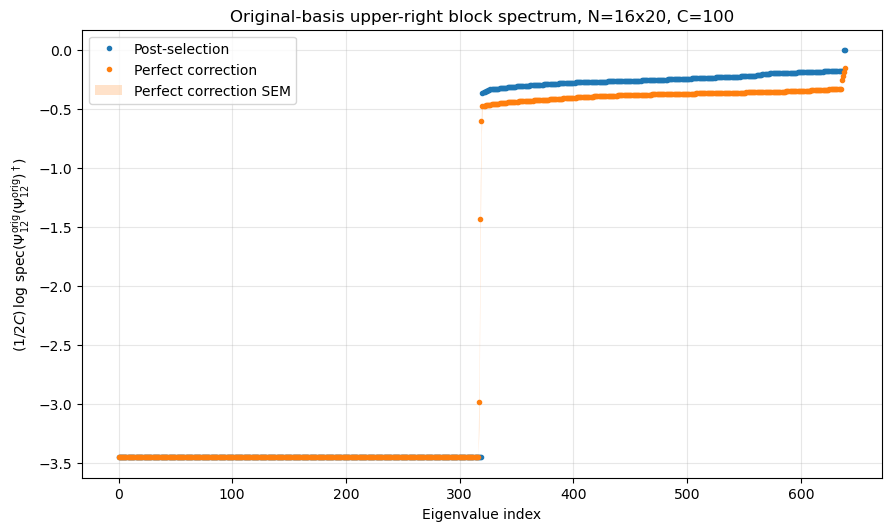

In [7]:
UPPER_RIGHT_OUTPUT_FIG = FIG_DIR / "complex_upper_right_block_spectrum_N16x20_C100.png"

fig, ax = plt.subplots(figsize=(8.8, 5.2), constrained_layout=True)

plot_order = ["post_selection", "perfect_correction"]
colors = {"post_selection": "tab:blue", "perfect_correction": "tab:orange"}
labels = {"post_selection": "Post-selection", "perfect_correction": "Perfect correction"}

for protocol in plot_order:
    result = upper_right_spectra_by_protocol[protocol]
    x = np.arange(result["mean"].size)
    ax.plot(x, result["mean"], linestyle=" ", marker=".", color=colors[protocol], label=labels[protocol])
    if result["samples"].shape[0] > 1:
        ax.fill_between(
            x,
            result["mean"] - result["sem"],
            result["mean"] + result["sem"],
            color=colors[protocol],
            alpha=0.22,
            linewidth=0,
            label=f"{labels[protocol]} SEM",
        )

ax.set_xlabel("Eigenvalue index")
ax.set_ylabel(r"$(1 / 2C)\,\log\,\mathrm{spec}(\Psi_{12}^{\mathrm{orig}}(\Psi_{12}^{\mathrm{orig}})^\dagger)$")
ax.set_title(f"Original-basis upper-right block spectrum, N={Nx}x{Ny}, C={cycles}")
ax.grid(alpha=0.3)
ax.legend(loc="best")

fig.savefig(UPPER_RIGHT_OUTPUT_FIG, dpi=200)
UPPER_RIGHT_OUTPUT_FIG

PosixPath('/home/abhuiyan/class_A_fermionic_adaptive_circuit/lyapunov_analysis_v2/figs/majorana_vs_complex_upper_right_histograms_N16x20_C100.png')

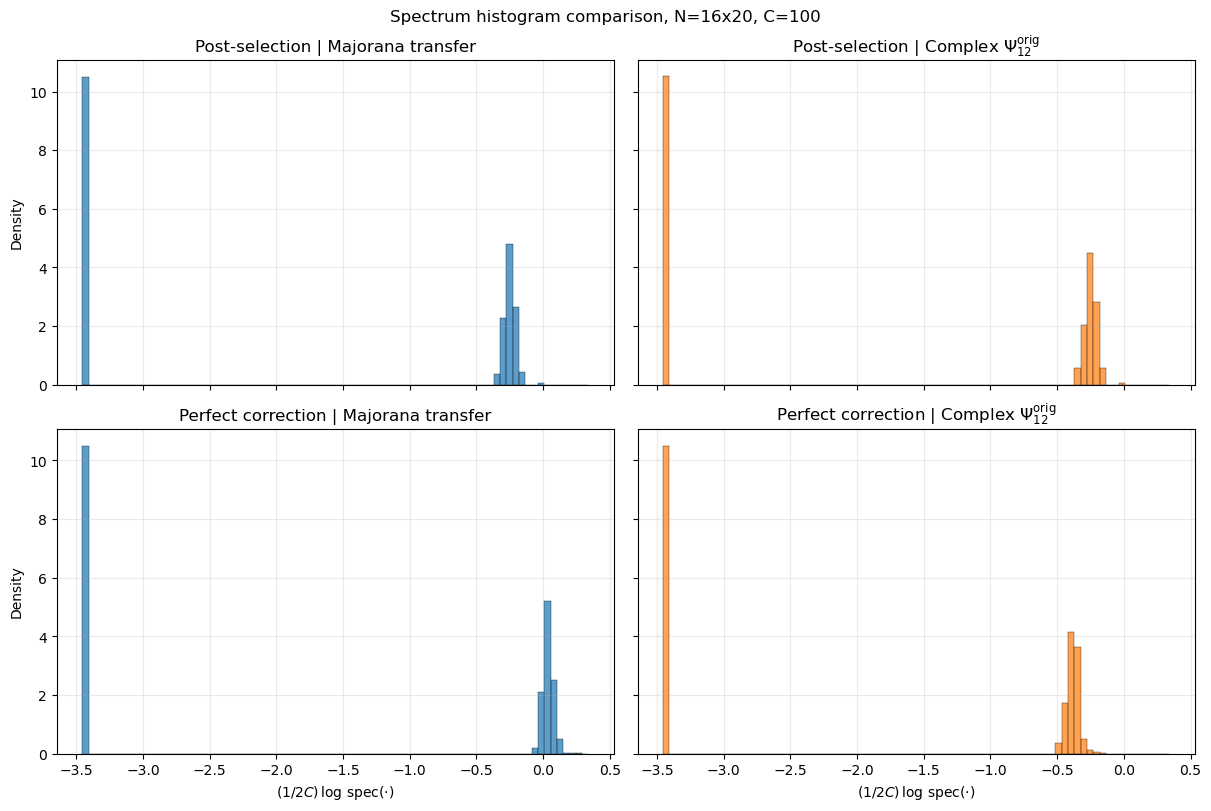

In [8]:
HIST_COMPARISON_OUTPUT_FIG = FIG_DIR / "majorana_vs_complex_upper_right_histograms_N16x20_C100.png"
HIST_BINS = 80

protocol_order = ["post_selection", "perfect_correction"]
protocol_labels = {"post_selection": "Post-selection", "perfect_correction": "Perfect correction"}
analysis_specs = [
    ("Majorana transfer", spectra_by_protocol, "tab:blue"),
    (r"Complex $\Psi_{12}^{\mathrm{orig}}$", upper_right_spectra_by_protocol, "tab:orange"),
]

hist_values = {}
for analysis_label, spectra_dict, _ in analysis_specs:
    hist_values[analysis_label] = {}
    for protocol in protocol_order:
        values = np.asarray(spectra_dict[protocol]["samples"], dtype=np.float64).ravel()
        assert values.size > 0, f"No spectrum values for {analysis_label} / {protocol}"
        assert np.all(np.isfinite(values)), f"Non-finite spectrum values for {analysis_label} / {protocol}"
        hist_values[analysis_label][protocol] = values

combined_hist_values = np.concatenate([
    hist_values[analysis_label][protocol]
    for analysis_label, _, _ in analysis_specs
    for protocol in protocol_order
])
bin_edges = np.histogram_bin_edges(combined_hist_values, bins=HIST_BINS)
if bin_edges.size < 2 or np.isclose(bin_edges[0], bin_edges[-1]):
    center = float(combined_hist_values[0])
    bin_edges = np.linspace(center - 0.5, center + 0.5, HIST_BINS + 1)
assert bin_edges.ndim == 1 and bin_edges.size == HIST_BINS + 1

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True, constrained_layout=True)
for row, protocol in enumerate(protocol_order):
    for col, (analysis_label, _, color) in enumerate(analysis_specs):
        ax = axes[row, col]
        ax.hist(
            hist_values[analysis_label][protocol],
            bins=bin_edges,
            density=True,
            color=color,
            alpha=0.72,
            edgecolor="black",
            linewidth=0.35,
        )
        ax.set_title(f"{protocol_labels[protocol]} | {analysis_label}")
        ax.grid(alpha=0.25)

for ax in axes[-1, :]:
    ax.set_xlabel(r"$(1 / 2C)\,\log\,\mathrm{spec}(\cdot)$")
for ax in axes[:, 0]:
    ax.set_ylabel("Density")

fig.suptitle(f"Spectrum histogram comparison, N={Nx}x{Ny}, C={cycles}")
fig.savefig(HIST_COMPARISON_OUTPUT_FIG, dpi=200)

assert HIST_COMPARISON_OUTPUT_FIG.exists(), f"Histogram figure was not written: {HIST_COMPARISON_OUTPUT_FIG}"
HIST_COMPARISON_OUTPUT_FIG

PosixPath('/home/abhuiyan/class_A_fermionic_adaptive_circuit/lyapunov_analysis_v2/figs/majorana_vs_complex_upper_right_mean_spectrum_N16x20_C100.png')

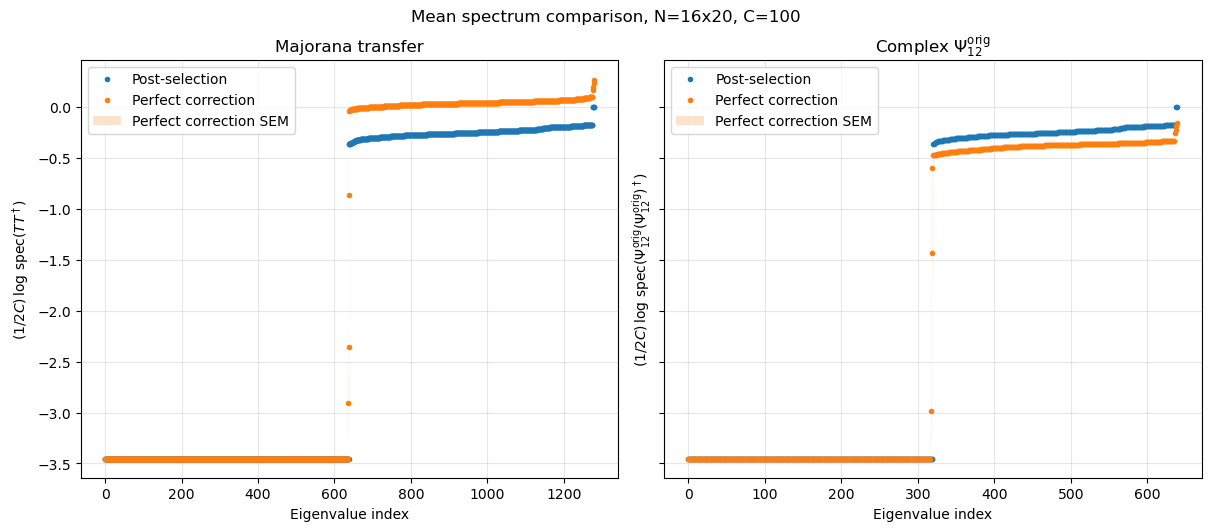

In [9]:
MEAN_COMPARISON_OUTPUT_FIG = FIG_DIR / "majorana_vs_complex_upper_right_mean_spectrum_N16x20_C100.png"

plot_order = ["post_selection", "perfect_correction"]
colors = {"post_selection": "tab:blue", "perfect_correction": "tab:orange"}
labels = {"post_selection": "Post-selection", "perfect_correction": "Perfect correction"}
analysis_specs = [
    ("Majorana transfer", spectra_by_protocol, r"$(1 / 2C)\,\log\,\mathrm{spec}(T T^\dagger)$"),
    (r"Complex $\Psi_{12}^{\mathrm{orig}}$", upper_right_spectra_by_protocol, r"$(1 / 2C)\,\log\,\mathrm{spec}(\Psi_{12}^{\mathrm{orig}}(\Psi_{12}^{\mathrm{orig}})^\dagger)$"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True, constrained_layout=True)
for ax, (analysis_label, spectra_dict, ylabel) in zip(axes, analysis_specs):
    for protocol in plot_order:
        result = spectra_dict[protocol]
        x = np.arange(result["mean"].size)
        ax.plot(x, result["mean"], linestyle=" ", marker=".", color=colors[protocol], label=labels[protocol])
        if result["samples"].shape[0] > 1:
            ax.fill_between(
                x,
                result["mean"] - result["sem"],
                result["mean"] + result["sem"],
                color=colors[protocol],
                alpha=0.22,
                linewidth=0,
                label=f"{labels[protocol]} SEM",
            )
    ax.set_xlabel("Eigenvalue index")
    ax.set_title(analysis_label)
    ax.grid(alpha=0.3)
    ax.legend(loc="best")

axes[0].set_ylabel(analysis_specs[0][2])
axes[1].set_ylabel(analysis_specs[1][2])
fig.suptitle(f"Mean spectrum comparison, N={Nx}x{Ny}, C={cycles}")
fig.savefig(MEAN_COMPARISON_OUTPUT_FIG, dpi=200)
MEAN_COMPARISON_OUTPUT_FIG

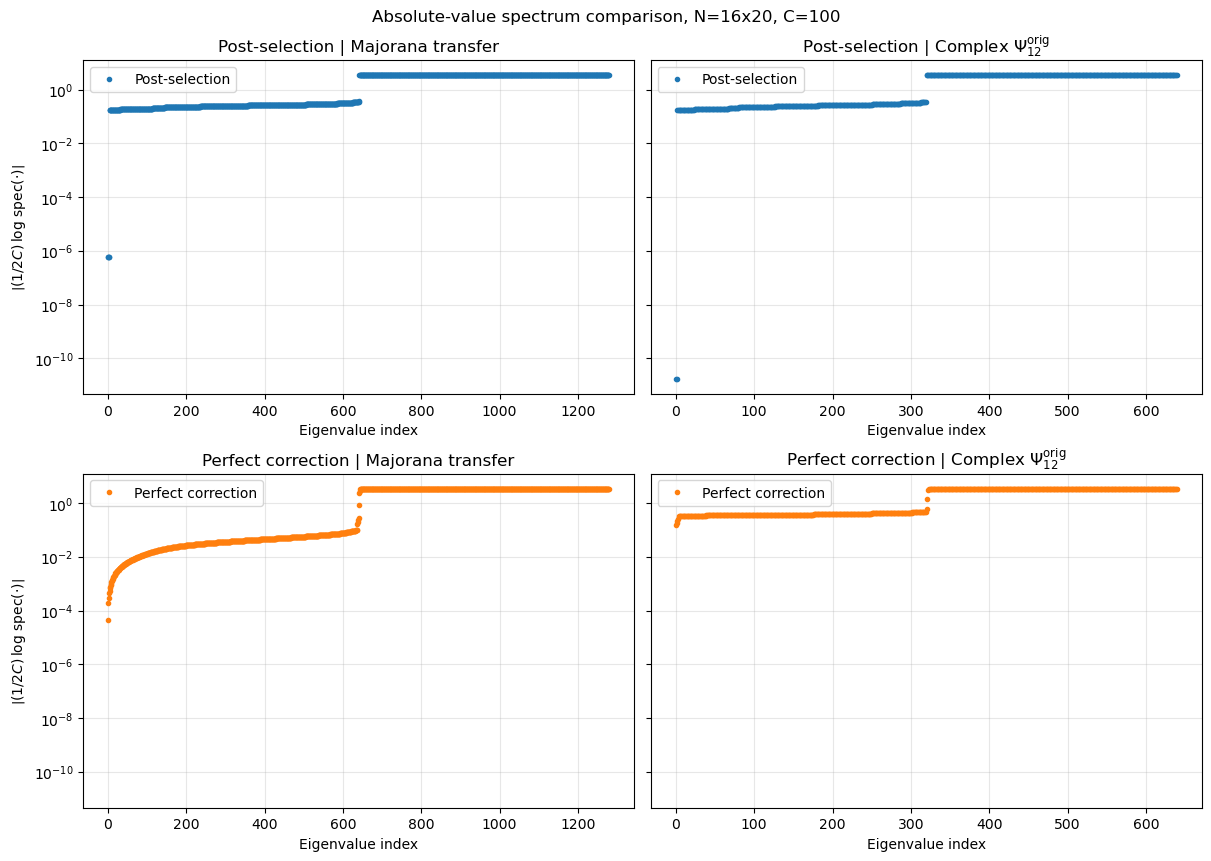

,rank,original_eigenvalue_index,sign,signed_value,abs_value
0,0,1277,-,-5.808432e-07,5.808432e-07
1,1,1276,-,-5.808432e-07,5.808432e-07
2,2,1278,+,5.808432e-07,5.808432e-07
3,3,1279,+,5.808432e-07,5.808432e-07
4,4,1275,-,-1.714560e-01,1.714560e-01
...,...,...,...,...,...
1275,1275,35,-,-3.453878e+00,3.453878e+00
1276,1276,36,-,-3.453878e+00,3.453878e+00
1277,1277,37,-,-3.453878e+00,3.453878e+00
1278,1278,38,-,-3.453878e+00,3.453878e+00


,rank,original_eigenvalue_index,sign,signed_value,abs_value
0,0,707,+,0.000046,0.000046
1,1,706,-,-0.000194,0.000194
2,2,708,+,0.000305,0.000305
3,3,705,-,-0.000446,0.000446
4,4,709,+,0.000554,0.000554
...,...,...,...,...,...
1275,1275,36,-,-3.453878,3.453878
1276,1276,37,-,-3.453878,3.453878
1277,1277,38,-,-3.453878,3.453878
1278,1278,39,-,-3.453878,3.453878


,rank,original_eigenvalue_index,sign,signed_value,abs_value
0,0,639,-,-1.687761e-11,1.687761e-11
1,1,638,-,-1.687829e-11,1.687829e-11
2,2,637,-,-1.742407e-01,1.742407e-01
3,3,636,-,-1.746301e-01,1.746301e-01
4,4,635,-,-1.750052e-01,1.750052e-01
...,...,...,...,...,...
635,635,35,-,-3.453878e+00,3.453878e+00
636,636,36,-,-3.453878e+00,3.453878e+00
637,637,37,-,-3.453878e+00,3.453878e+00
638,638,38,-,-3.453878e+00,3.453878e+00


,rank,original_eigenvalue_index,sign,signed_value,abs_value
0,0,639,-,-0.154654,0.154654
1,1,638,-,-0.185732,0.185732
2,2,637,-,-0.223743,0.223743
3,3,636,-,-0.258227,0.258227
4,4,635,-,-0.328572,0.328572
...,...,...,...,...,...
635,635,35,-,-3.453878,3.453878
636,636,36,-,-3.453878,3.453878
637,637,37,-,-3.453878,3.453878
638,638,38,-,-3.453878,3.453878


In [10]:
import pandas as pd
ABS_COMPARISON_OUTPUT_FIG = FIG_DIR / "majorana_vs_complex_upper_right_abs_spectrum_N16x20_C100.png"

plot_order = ["post_selection", "perfect_correction"]
colors = {"post_selection": "tab:blue", "perfect_correction": "tab:orange"}
labels = {"post_selection": "Post-selection", "perfect_correction": "Perfect correction"}
analysis_specs = [
    ("majorana", "Majorana transfer", spectra_by_protocol),
    ("complex_upper_right", r"Complex $\Psi_{12}^{\mathrm{orig}}$", upper_right_spectra_by_protocol),
]

comparison_spectrum_dfs = {analysis_key: {} for analysis_key, _, _ in analysis_specs}

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), sharey=True, constrained_layout=True)
for row, protocol in enumerate(plot_order):
    for col, (analysis_key, analysis_label, spectra_dict) in enumerate(analysis_specs):
        ax = axes[row, col]
        result = spectra_dict[protocol]
        signed = np.asarray(result["mean"], dtype=float)
        order = np.argsort(np.abs(signed))
        signed_sorted = signed[order]
        abs_sorted = np.abs(signed_sorted)
        x = np.arange(abs_sorted.size)

        ax.plot(
            x,
            abs_sorted,
            linestyle=" ",
            marker=".",
            color=colors[protocol],
            label=labels[protocol],
        )
        ax.set_yscale("log")
        ax.set_xlabel("Eigenvalue index")
        ax.set_title(f"{labels[protocol]} | {analysis_label}")
        ax.grid(alpha=0.3)
        ax.legend(loc="best")

        comparison_spectrum_dfs[analysis_key][protocol] = pd.DataFrame({
            "rank": np.arange(abs_sorted.size),
            "original_eigenvalue_index": order.astype(int),
            "sign": np.where(signed_sorted > 0, "+", np.where(signed_sorted < 0, "-", "0")),
            "signed_value": signed_sorted,
            "abs_value": abs_sorted,
        })

for ax in axes[:, 0]:
    ax.set_ylabel(r"$\left|(1 / 2C)\,\log\,\mathrm{spec}(\cdot)\right|$")

fig.suptitle(f"Absolute-value spectrum comparison, N={Nx}x{Ny}, C={cycles}")
fig.savefig(ABS_COMPARISON_OUTPUT_FIG, dpi=200)
plt.show()

majorana_post_selection_df = comparison_spectrum_dfs["majorana"]["post_selection"]
majorana_perfect_correction_df = comparison_spectrum_dfs["majorana"]["perfect_correction"]
complex_upper_right_post_selection_df = comparison_spectrum_dfs["complex_upper_right"]["post_selection"]
complex_upper_right_perfect_correction_df = comparison_spectrum_dfs["complex_upper_right"]["perfect_correction"]

display(majorana_post_selection_df)
display(majorana_perfect_correction_df)
display(complex_upper_right_post_selection_df)
display(complex_upper_right_perfect_correction_df)


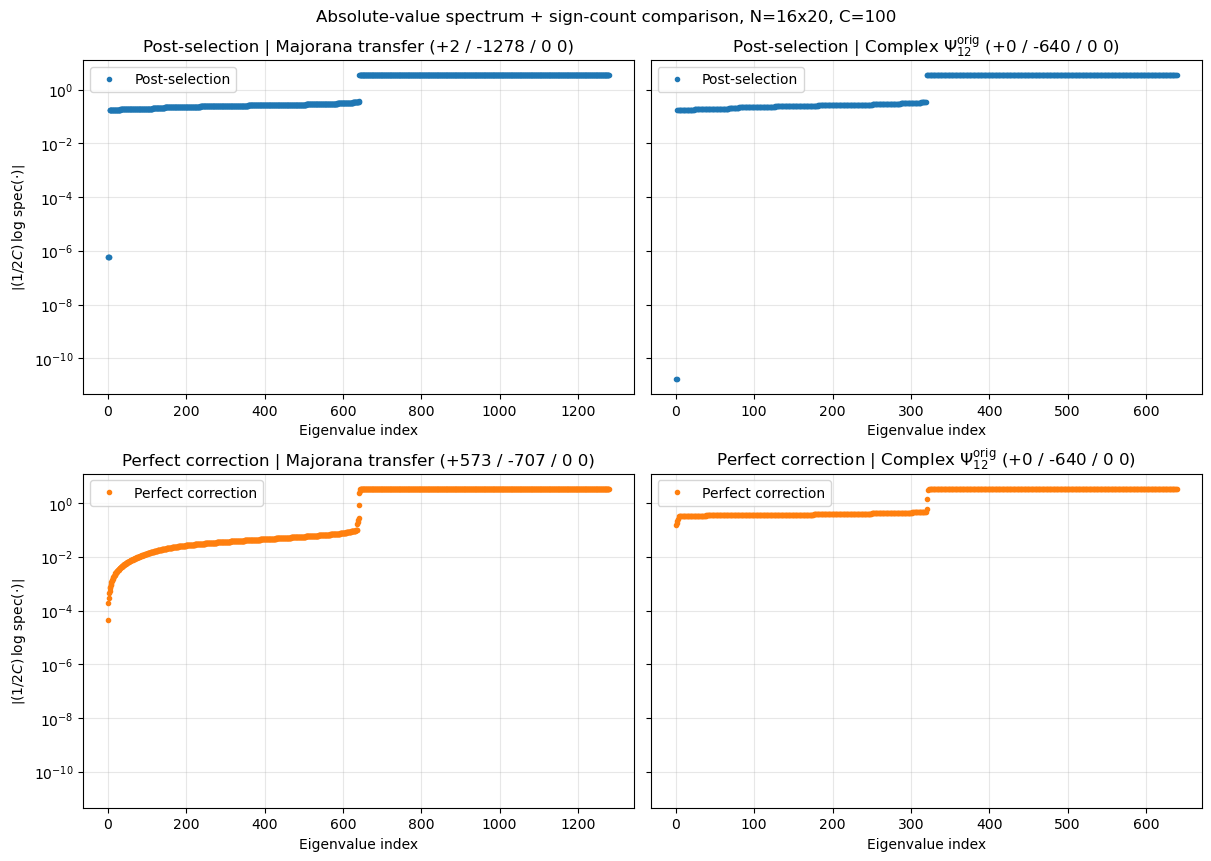

,analysis,protocol,positive,negative,zero,total
0,Majorana transfer,Post-selection,2,1278,0,1280
1,Complex $\Psi_{12}^{\mathrm{orig}}$,Post-selection,0,640,0,640
2,Majorana transfer,Perfect correction,573,707,0,1280
3,Complex $\Psi_{12}^{\mathrm{orig}}$,Perfect correction,0,640,0,640


,rank,original_eigenvalue_index,sign,signed_value,abs_value
0,0,1277,-,-5.808432e-07,5.808432e-07
1,1,1276,-,-5.808432e-07,5.808432e-07
2,2,1278,+,5.808432e-07,5.808432e-07
3,3,1279,+,5.808432e-07,5.808432e-07
4,4,1275,-,-1.714560e-01,1.714560e-01
...,...,...,...,...,...
1275,1275,35,-,-3.453878e+00,3.453878e+00
1276,1276,36,-,-3.453878e+00,3.453878e+00
1277,1277,37,-,-3.453878e+00,3.453878e+00
1278,1278,38,-,-3.453878e+00,3.453878e+00


,rank,original_eigenvalue_index,sign,signed_value,abs_value
0,0,707,+,0.000046,0.000046
1,1,706,-,-0.000194,0.000194
2,2,708,+,0.000305,0.000305
3,3,705,-,-0.000446,0.000446
4,4,709,+,0.000554,0.000554
...,...,...,...,...,...
1275,1275,36,-,-3.453878,3.453878
1276,1276,37,-,-3.453878,3.453878
1277,1277,38,-,-3.453878,3.453878
1278,1278,39,-,-3.453878,3.453878


,rank,original_eigenvalue_index,sign,signed_value,abs_value
0,0,639,-,-1.687761e-11,1.687761e-11
1,1,638,-,-1.687829e-11,1.687829e-11
2,2,637,-,-1.742407e-01,1.742407e-01
3,3,636,-,-1.746301e-01,1.746301e-01
4,4,635,-,-1.750052e-01,1.750052e-01
...,...,...,...,...,...
635,635,35,-,-3.453878e+00,3.453878e+00
636,636,36,-,-3.453878e+00,3.453878e+00
637,637,37,-,-3.453878e+00,3.453878e+00
638,638,38,-,-3.453878e+00,3.453878e+00


,rank,original_eigenvalue_index,sign,signed_value,abs_value
0,0,639,-,-0.154654,0.154654
1,1,638,-,-0.185732,0.185732
2,2,637,-,-0.223743,0.223743
3,3,636,-,-0.258227,0.258227
4,4,635,-,-0.328572,0.328572
...,...,...,...,...,...
635,635,35,-,-3.453878,3.453878
636,636,36,-,-3.453878,3.453878
637,637,37,-,-3.453878,3.453878
638,638,38,-,-3.453878,3.453878


In [11]:
ABS_SIGN_COMPARISON_OUTPUT_FIG = FIG_DIR / "majorana_vs_complex_upper_right_abs_spectrum_sign_counts_N16x20_C100.png"

plot_order = ["post_selection", "perfect_correction"]
colors = {"post_selection": "tab:blue", "perfect_correction": "tab:orange"}
labels = {"post_selection": "Post-selection", "perfect_correction": "Perfect correction"}
analysis_specs = [
    ("majorana", "Majorana transfer", spectra_by_protocol),
    ("complex_upper_right", r"Complex $\Psi_{12}^{\mathrm{orig}}$", upper_right_spectra_by_protocol),
]

comparison_spectrum_dfs = {analysis_key: {} for analysis_key, _, _ in analysis_specs}
sign_count_rows = []

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), sharey=True, constrained_layout=True)
for row, protocol in enumerate(plot_order):
    for col, (analysis_key, analysis_label, spectra_dict) in enumerate(analysis_specs):
        ax = axes[row, col]
        result = spectra_dict[protocol]
        signed = np.asarray(result["mean"], dtype=float)
        order = np.argsort(np.abs(signed))
        signed_sorted = signed[order]
        abs_sorted = np.abs(signed_sorted)

        n_pos = int(np.count_nonzero(signed > 0))
        n_neg = int(np.count_nonzero(signed < 0))
        n_zero = int(np.count_nonzero(signed == 0))

        sign_count_rows.append({
            "analysis": analysis_label,
            "protocol": labels[protocol],
            "positive": n_pos,
            "negative": n_neg,
            "zero": n_zero,
            "total": signed.size,
        })

        x = np.arange(abs_sorted.size)
        ax.plot(
            x,
            abs_sorted,
            linestyle=" ",
            marker=".",
            color=colors[protocol],
            label=labels[protocol],
        )
        ax.set_yscale("log")
        ax.set_xlabel("Eigenvalue index")
        ax.set_title(f"{labels[protocol]} | {analysis_label} (+{n_pos} / -{n_neg} / 0 {n_zero})")
        ax.grid(alpha=0.3)
        ax.legend(loc="best")

        comparison_spectrum_dfs[analysis_key][protocol] = pd.DataFrame({
            "rank": np.arange(abs_sorted.size),
            "original_eigenvalue_index": order.astype(int),
            "sign": np.where(signed_sorted > 0, "+", np.where(signed_sorted < 0, "-", "0")),
            "signed_value": signed_sorted,
            "abs_value": abs_sorted,
        })

for ax in axes[:, 0]:
    ax.set_ylabel(r"$\left|(1 / 2C)\,\log\,\mathrm{spec}(\cdot)\right|$")

fig.suptitle(f"Absolute-value spectrum + sign-count comparison, N={Nx}x{Ny}, C={cycles}")
fig.savefig(ABS_SIGN_COMPARISON_OUTPUT_FIG, dpi=200)
plt.show()

comparison_sign_counts_df = pd.DataFrame(sign_count_rows)
majorana_post_selection_df = comparison_spectrum_dfs["majorana"]["post_selection"]
majorana_perfect_correction_df = comparison_spectrum_dfs["majorana"]["perfect_correction"]
complex_upper_right_post_selection_df = comparison_spectrum_dfs["complex_upper_right"]["post_selection"]
complex_upper_right_perfect_correction_df = comparison_spectrum_dfs["complex_upper_right"]["perfect_correction"]

display(comparison_sign_counts_df)
display(majorana_post_selection_df)
display(majorana_perfect_correction_df)
display(complex_upper_right_post_selection_df)
display(complex_upper_right_perfect_correction_df)


In [12]:
payload = {
    "source_file": np.array(str(SOURCE_FILE)),
    "config_json": np.array(json.dumps(config, sort_keys=True)),
    "cycles": np.array(cycles, dtype=int),
    "Nx": np.array(Nx, dtype=int),
    "Ny": np.array(Ny, dtype=int),
    "diagnostics_json": np.array(json.dumps(diagnostics_by_protocol, sort_keys=True)),
    "upper_right_diagnostics_json": np.array(json.dumps(upper_right_diagnostics_by_protocol, sort_keys=True)),
}
for protocol, result in spectra_by_protocol.items():
    payload[f"{protocol}_spectra"] = result["samples"]
    payload[f"{protocol}_mean"] = result["mean"]
    payload[f"{protocol}_sem"] = result["sem"]
for protocol, result in upper_right_spectra_by_protocol.items():
    payload[f"{protocol}_upper_right_spectra"] = result["samples"]
    payload[f"{protocol}_upper_right_mean"] = result["mean"]
    payload[f"{protocol}_upper_right_sem"] = result["sem"]

np.savez_compressed(OUTPUT_DATA, **payload)
OUTPUT_DATA

PosixPath('/home/abhuiyan/class_A_fermionic_adaptive_circuit/lyapunov_analysis_v2/cache/majorana_transfer_spectrum_N16x20_C100.npz')